In [84]:
### This script is used to analyze the 2p data of prism animals (V1)
### 1) Cell density, 2) cell size, and 3) Fneuropil are calculated along cortical layers
### layer4bin needs to be edited, if opticalZoom changes from 1.85x, using the Nikon 16x objective configuration

In [85]:
cd "C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation"

C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation


**Load 2p data**

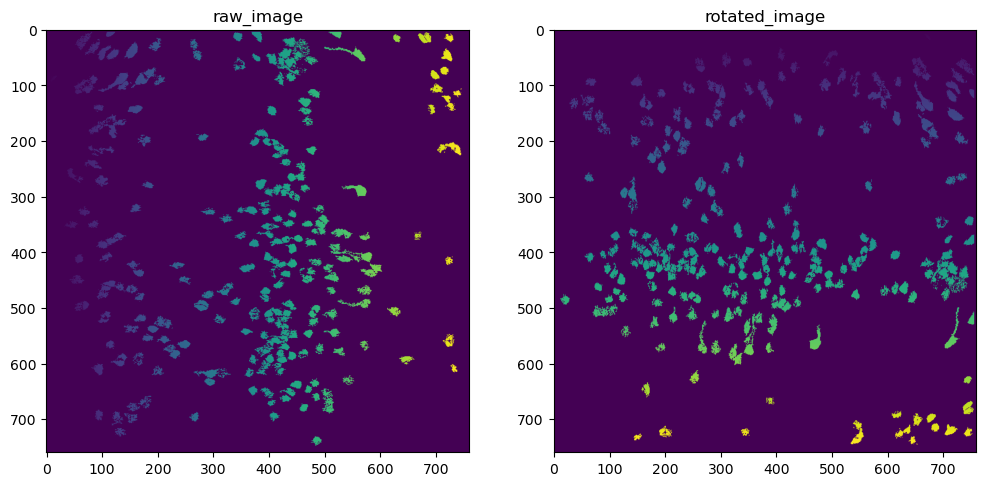

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Load 2p data
filepath = r'D:\V1_SpatialModulation\2p\250205_JSY_JSY041_PrismTest\TSeries-02052025-1306-Cousa-003\suite2p\plane0'
savedirectory = r'D:\V1_SpatialModulation\2p\250205_JSY_JSY041_PrismTest\TSeries-02052025-1306-Cousa-003'
# pop up input prompt for the animalID
animalID = input("Enter the animal ID: ")

Fneu = np.load(os.path.join(filepath, 'Fneu.npy'), allow_pickle=True)
iscell = np.load(os.path.join(filepath, 'iscell.npy'), allow_pickle=True)
stat = np.load(os.path.join(filepath, 'stat.npy'), allow_pickle=True)
ops = np.load(os.path.join(filepath, 'ops.npy'), allow_pickle=True).item()

usecells = iscell[:,0]==1
FneuCellAvg = np.mean(Fneu, axis=1)  # Average neuropil over cells

im = np.zeros((ops['Ly'], ops['Lx']))  # Create an empty image

ncells = len(stat)

for n in range(0, ncells):
    ypix = stat[n]['ypix'][~stat[n]['overlap']]
    xpix = stat[n]['xpix'][~stat[n]['overlap']]
    im[ypix, xpix] = xpix  # Assign xpix values to im for progressive color change along x-axis

im_rotated = np.rot90(im, k=-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(im)
ax1.set_title("raw_image")

ax2.imshow(im_rotated)
ax2.set_title("rotated_image")
plt.show()


In [2]:
# show the fields of variable stat
stat[0].keys()

dict_keys(['ypix', 'xpix', 'lam', 'med', 'footprint', 'mrs', 'mrs0', 'compact', 'solidity', 'npix', 'npix_soma', 'soma_crop', 'overlap', 'radius', 'aspect_ratio', 'npix_norm_no_crop', 'npix_norm', 'skew', 'std', 'neuropil_mask'])

**Cell Density**

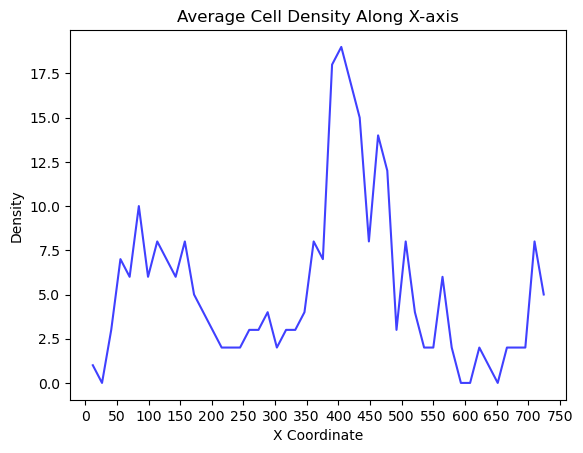

X-coordinate range: 12 to 739


In [87]:
# Extract the median coordinates of each cell
med_coords = np.array([cell['med'] for cell in stat])

# Calculate the density along the x-axis
density, bins = np.histogram(med_coords[:, 1], bins=50)

# Plot the average cell density along the x-axis
plt.figure()
plt.plot(bins[:-1], density, alpha=0.75, color='blue')
# plt.axvline(avg_density_x, color='red', linestyle='dashed', linewidth=1)
plt.title('Average Cell Density Along X-axis')
plt.xlabel('X Coordinate')
plt.xticks(np.arange(0, 760, 50))
plt.ylabel('Density')
plt.show()


print(f"X-coordinate range: {med_coords[:, 1].min()} to {med_coords[:, 1].max()}")

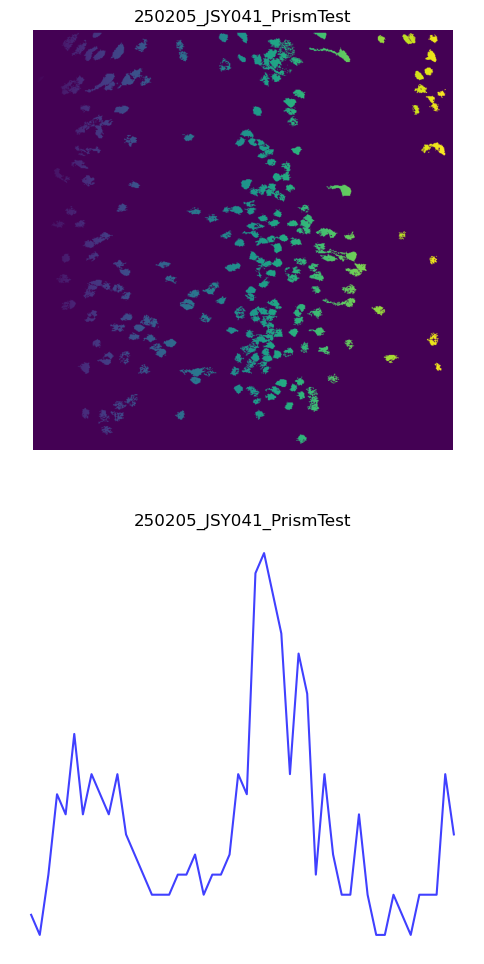

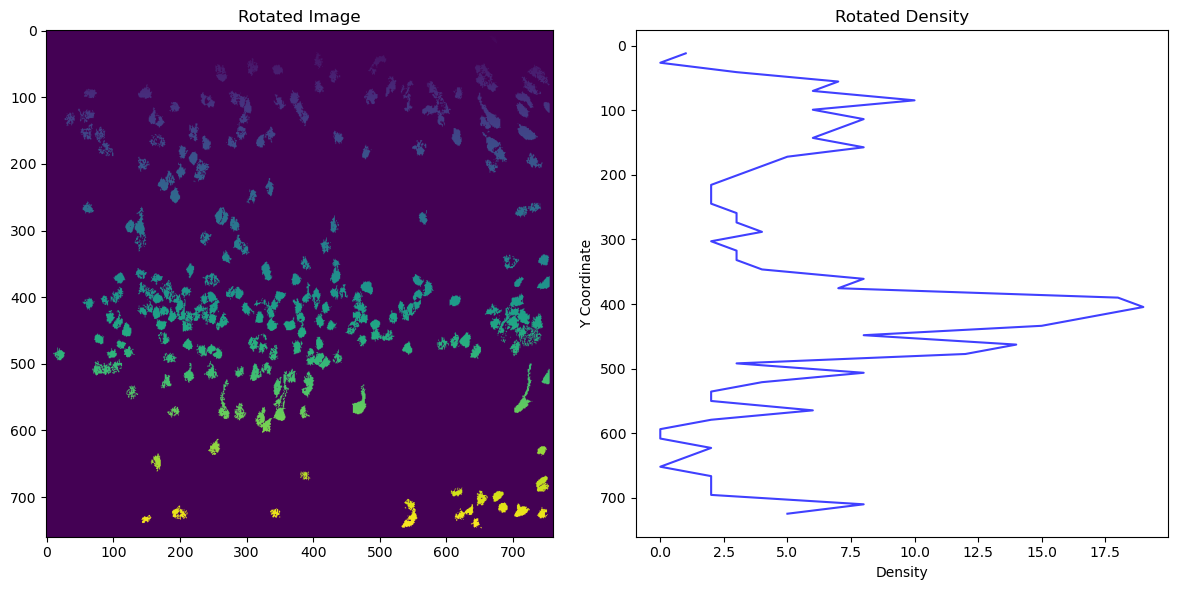

In [88]:
# Plot the image and density
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 12))

ax1.imshow(im, cmap='viridis')
ax1.set_title('250205_JSY041_PrismTest')
ax1.axis('off')

ax2.plot(bins[:-1], density, alpha=0.75, color='blue')

ax2.set_title('250205_JSY041_PrismTest')
ax2.axis('off')

plt.show()

# Plot the rotated images and density
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

im_rotated = np.rot90(im, k=-1)
ax1.imshow(im_rotated, cmap='viridis')
ax1.set_title("Rotated Image")

ax2.plot(density, bins[:-1], alpha=0.75, color='blue')
ax2.invert_yaxis()
ax2.set_title("Rotated Density")
ax2.set_xlabel('Density')
ax2.set_ylabel('Y Coordinate')

plt.tight_layout()
plt.show()

C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_36200\2554811611.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


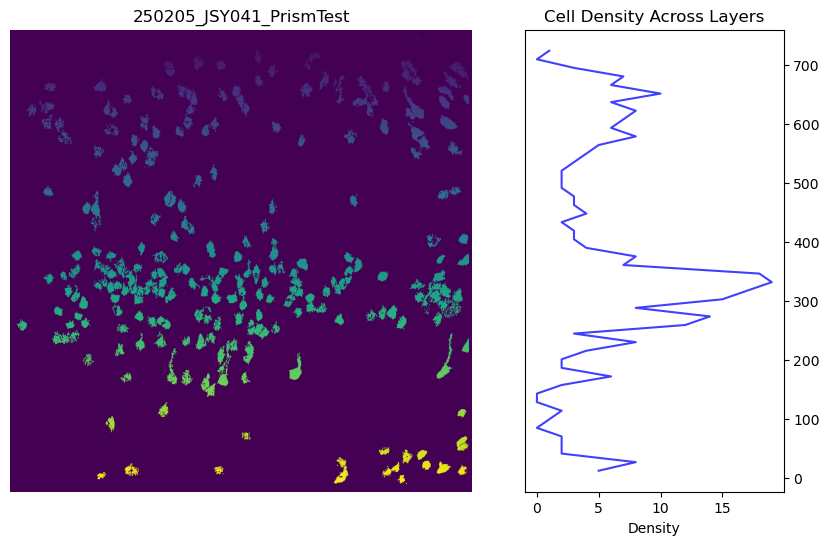

In [89]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [3, 1], 'wspace': -0.2})
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()

# Rotate the first plot 90 degrees clockwise
im_rotated = np.rot90(im, k=-1)
ax1.imshow(im_rotated, cmap='viridis')
ax1.set_title('250205_JSY041_PrismTest')
ax1.axis('off')

# Rotate the second plot 90 degrees counterclockwise and flip horizontally
density_rotated = np.rot90(density.reshape(-1, 1), k=1)
density_flipped = np.fliplr(density_rotated)
ax2.plot(density_flipped[0], bins[:-1], alpha=0.75, color='blue')
# ax2.plot(density_flipped[0], bins[:-1], alpha=0.75, color='blue')
ax2.set_title('Cell Density Across Layers')
ax2.set_xlabel('Density')

plt.tight_layout()
plt.show()


**ROI size and Fneu**

Text(0.5, 0.98, 'Fneu along x-axis')

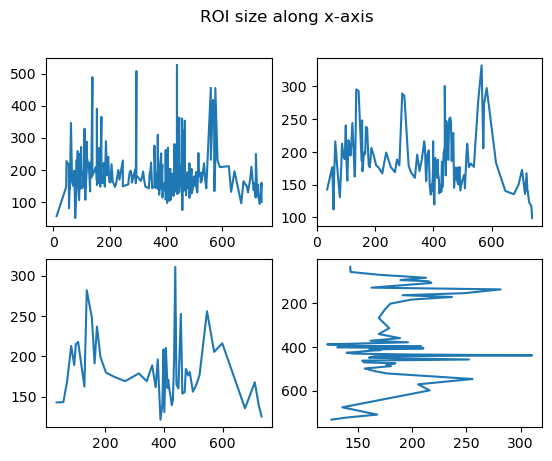

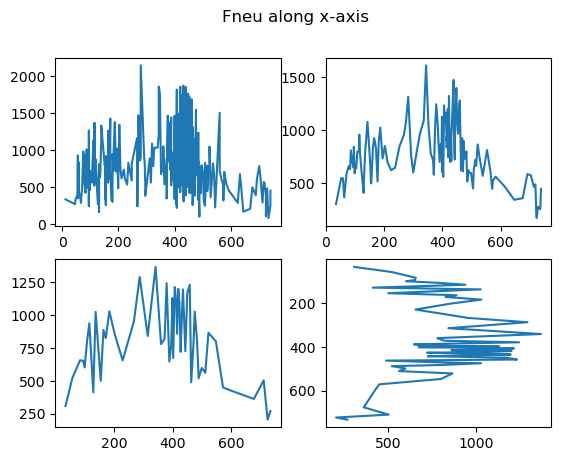

In [90]:
# Extract the median coordinates and ROI size of each cell
med_coords = np.array([cell['med'][1] for cell in stat])
ROIsize = np.array([cell['npix'] for cell in stat])

# Sort ROI sizes/F_neu by median coordinates
sort_med_coords_indice = np.argsort(med_coords)
sort_ROIsize = ROIsize[sort_med_coords_indice]
sort_Fneu = FneuCellAvg[sort_med_coords_indice]

# Calculate the average of every 3 sorted ROI sizes/F_neu and median coordinates
avg_ROIsize = [np.mean(sort_ROIsize[i:i+3]) for i in range(0, len(sort_ROIsize), 2)]
avg_med_coords = [np.mean(med_coords[sort_med_coords_indice][i:i+3]) for i in range(0, len(sort_med_coords_indice), 2)]
avg_Fneu = [np.mean(sort_Fneu[i:i+3]) for i in range(0, len(sort_Fneu), 2)]

# Calculate the average of every 5 sorted ROI sizes/F_neu and median coordinates
avg5_ROIsize = [np.mean(sort_ROIsize[i:i+3]) for i in range(0, len(sort_ROIsize), 5)]
avg5_med_coords = [np.mean(med_coords[sort_med_coords_indice][i:i+3]) for i in range(0, len(sort_med_coords_indice), 5)]
avg5_Fneu = [np.mean(sort_Fneu[i:i+3]) for i in range(0, len(sort_Fneu), 5)]

figure, ax = plt.subplots(2,2)
ax[0,0].plot(med_coords[sort_med_coords_indice],sort_ROIsize)
ax[0,1].plot(avg_med_coords, avg_ROIsize)
ax[1,0].plot(avg5_med_coords, avg5_ROIsize)
ax[1,1].plot(avg5_ROIsize, avg5_med_coords)
ax[1,1].invert_yaxis()
figure.suptitle('ROI size along x-axis')

figure, ax = plt.subplots(2,2)
ax[0,0].plot(med_coords[sort_med_coords_indice],sort_Fneu)
ax[0,1].plot(avg_med_coords, avg_Fneu)
ax[1,0].plot(avg5_med_coords, avg5_Fneu)
ax[1,1].plot(avg5_Fneu, avg5_med_coords)
ax[1,1].invert_yaxis()
figure.suptitle('Fneu along x-axis')

**Plot raw and smoothened data**

C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_36200\641250620.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


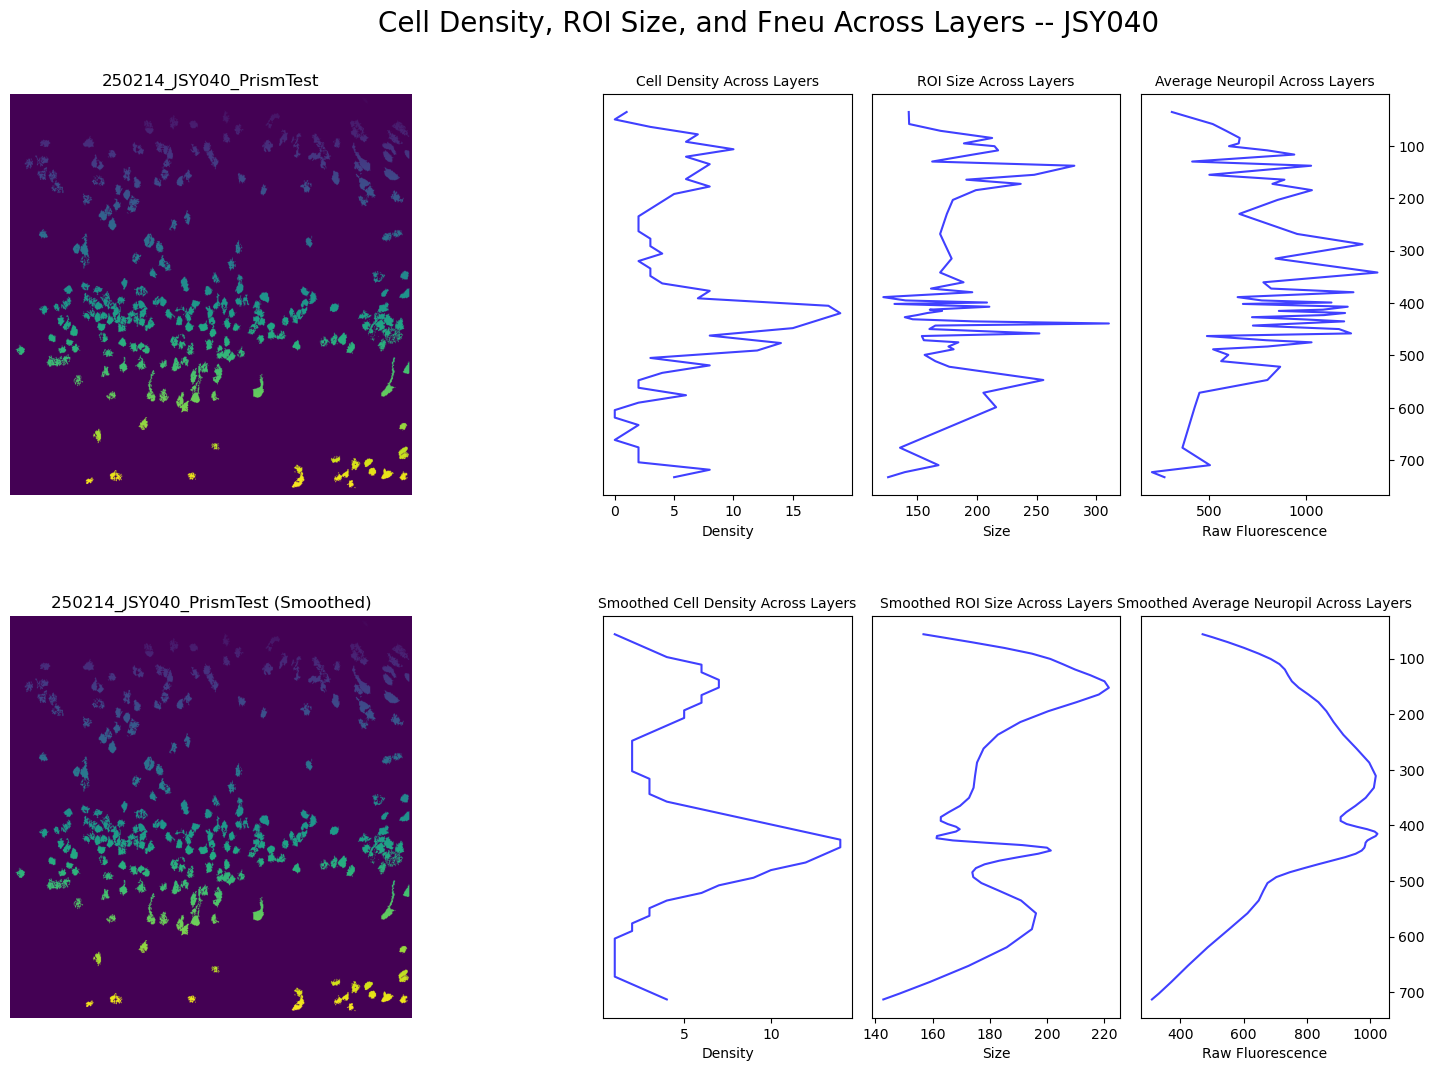

In [91]:
from scipy.ndimage import gaussian_filter1d

def smooth(data, sigma):
    return gaussian_filter1d(data, sigma=sigma)

fig, axes = plt.subplots(2, 4, figsize=(20, 12), gridspec_kw={'width_ratios': [3, 1, 1, 1], 'wspace': 0.055, 'hspace': 0.3})

# Plot the ROIs
im_rotated = np.rot90(im, k=-1)
axes[0, 0].imshow(im_rotated, cmap='viridis')
axes[0, 0].set_title('250214_JSY040_PrismTest')
axes[0, 0].axis('off')

# Plot the average cell density along the x-axis
density_rotated = np.rot90(density.reshape(-1, 1), k=-1)
axes[0, 1].plot(density, bins[:-1], alpha=0.75, color='blue')
axes[0, 1].invert_yaxis()
# axes[0, 1].plot(density_rotated[0][:len(bins[:-1])], bins[:-1], alpha=0.75, color='blue')
axes[0, 1].set_title('Cell Density Across Layers', fontsize=10)
axes[0, 1].set_xlabel('Density', fontsize=10)
axes[0, 1].set_yticks([])  # Remove y-axis

# Plot the ROI size along the x-axis
axes[0, 2].plot(avg5_ROIsize, avg5_med_coords, alpha=0.75, color='blue')
axes[0, 2].invert_yaxis()
axes[0, 2].set_title('ROI Size Across Layers', fontsize=10)
axes[0, 2].set_xlabel('Size', fontsize=10)
axes[0, 2].set_yticks([])  # Remove y-axis labels/ticks on the left

# Plot the average Fneu along the x-axis
axes[0, 3].plot(avg5_Fneu, avg5_med_coords, alpha=0.75, color='blue')
axes[0, 3].invert_yaxis()
axes[0, 3].set_title('Average Neuropil Across Layers', fontsize=10)
axes[0, 3].set_xlabel('Raw Fluorescence', fontsize=10)
axes[0, 3].yaxis.set_label_position("right")
axes[0, 3].yaxis.tick_right()

# Smooth the data
sigma = 2
smooth_density = smooth(density, sigma)
smooth_avg5_ROIsize = smooth(avg5_ROIsize, sigma)
smooth_avg5_Fneu = smooth(avg5_Fneu, sigma)
smooth_avg5_med_coords = smooth(avg5_med_coords, sigma)

# Plot the smoothed ROIs
axes[1, 0].imshow(im_rotated, cmap='viridis')
axes[1, 0].set_title('250214_JSY040_PrismTest (Smoothed)')
axes[1, 0].axis('off')

# Plot the smoothed cell density along the x-axis
density_rotated = np.rot90(smooth_density.reshape(-1, 1), k=-1)
axes[1, 1].plot(smooth_density[:len(bins[:-sigma])], bins[:-sigma], alpha=0.75, color='blue')
axes[1, 1].invert_yaxis()
# axes[1, 1].plot(density_rotated[0][:len(bins[:-sigma])], bins[:-sigma], alpha=0.75, color='blue')
axes[1, 1].set_title('Smoothed Cell Density Across Layers', fontsize=10)
axes[1, 1].set_xlabel('Density', fontsize=10)
axes[1, 1].set_yticks([])  # Remove y-axis

# Plot the smoothed ROI size along the x-axis
axes[1, 2].plot(smooth_avg5_ROIsize, smooth_avg5_med_coords, alpha=0.75, color='blue')
axes[1, 2].invert_yaxis()
axes[1, 2].set_title('Smoothed ROI Size Across Layers', fontsize=10)
axes[1, 2].set_xlabel('Size', fontsize=10)
axes[1, 2].set_yticks([])  # Remove y-axis labels/ticks on the left

# Plot the smoothed average Fneu along the x-axis
axes[1, 3].plot(smooth_avg5_Fneu, smooth_avg5_med_coords, alpha=0.75, color='blue')
axes[1, 3].invert_yaxis()
axes[1, 3].set_title('Smoothed Average Neuropil Across Layers', fontsize=10)
axes[1, 3].set_xlabel('Raw Fluorescence', fontsize=10)
axes[1, 3].yaxis.set_label_position("right")
axes[1, 3].yaxis.tick_right()

fig.suptitle('Cell Density, ROI Size, and Fneu Across Layers -- JSY040', fontsize=20, x=0.59, y=0.95)

plt.tight_layout()
plt.show()


**Define layers in visual cortex**

In [92]:
# find peak of smooth_density
peak_density = np.argmax(smooth_density)
peak_density_x = bins[peak_density]
print('Peak Density = ', peak_density_x)

# each pixel of smooth_density corresponds to 1 bin and 1 bin = 0.9423 um. Find bins +/- 70um away from peak_density
layer4bin = int(70/0.9423)
layer4_upper = peak_density_x + layer4bin
layer4_lower = peak_density_x - layer4bin
print('layer 4 range = ', layer4_lower, layer4_upper)   

layer23bin_upper = layer4_lower
layer23bin_lower = 0
print('layer 2/3 range = ', layer23bin_lower, layer23bin_upper)

layer5bin = int(150/0.9423)
layer5_lower = layer4_upper
layer5_upper = layer4_upper + layer5bin
print('layer 5 range = ', layer5_lower, layer5_upper)

# find the indices of cells within layer 4
layer4_cells = np.where((med_coords > layer4_lower) & (med_coords < layer4_upper))
# print(layer4_cells)

# find the indices of cells within layer 2/3
layer23_cells = np.where((med_coords > layer23bin_lower) & (med_coords < layer23bin_upper))

# find the indices of cells within layer 5
layer5_cells = np.where((med_coords > layer5_lower) & (med_coords < layer5_upper))

Peak Density =  404.58
layer 4 range =  330.58 478.58
layer 2/3 range =  0 330.58
layer 5 range =  478.58 637.5799999999999


**Plot with layers**

C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_36200\1634620369.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


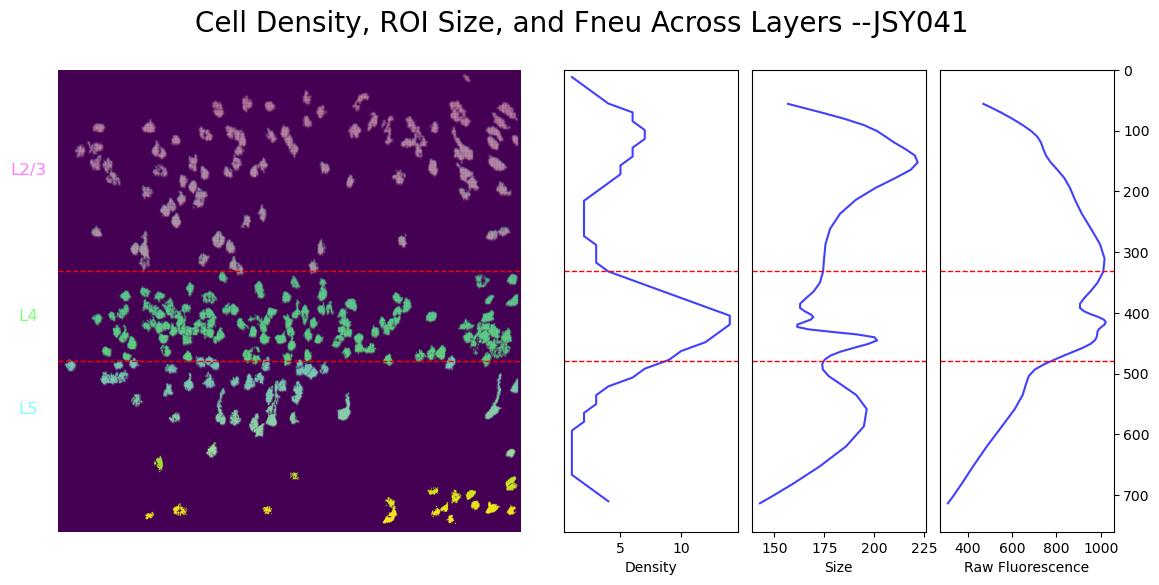

In [93]:
fig, axes = plt.subplots(1, 4, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1, 1, 1], 'wspace': 0.055, 'hspace': 0.3})

# Plot the smoothed ROIs
im_rotated = np.rot90(im, k=-1)
axes[0].imshow(im_rotated, cmap='viridis')
# Color the cells within layer 4 range differently with lower intensity
for cell in layer4_cells[0]:
    ypix = stat[cell]['ypix'][~stat[cell]['overlap']]
    xpix = stat[cell]['xpix'][~stat[cell]['overlap']]
    axes[0].scatter(ops['Ly'] - ypix - 1, xpix, color='lightgreen', s=1, alpha=0.05)
    
# Color the cells within layer 2/3 range differently with lower intensity
for cell in layer23_cells[0]:
    ypix = stat[cell]['ypix'][~stat[cell]['overlap']]
    xpix = stat[cell]['xpix'][~stat[cell]['overlap']]
    axes[0].scatter(ops['Ly'] - ypix - 1, xpix, color='lightpink', s=1, alpha=0.05)

# Color the cells within layer 5 range differently with lower intensity
for cell in layer5_cells[0]:
    ypix = stat[cell]['ypix'][~stat[cell]['overlap']]
    xpix = stat[cell]['xpix'][~stat[cell]['overlap']]
    axes[0].scatter(ops['Ly'] - ypix - 1, xpix, color='lightblue', s=1, alpha=0.05)

axes[0].axhline(layer4_lower, color='red', linestyle='dashed', linewidth=1)
axes[0].axhline(layer4_upper, color='red', linestyle='dashed', linewidth=1)
axes[0].axis('off')

# Add legends for the layers horizontally in the middle of each span
axes[0].text(-50, (layer23bin_upper + layer23bin_lower) / 2, 'L2/3', color='magenta', fontsize=12, ha='center', va='center', alpha=0.5)
axes[0].text(-50, (layer4_upper + layer4_lower) / 2, 'L4', color='lime', fontsize=12, ha='center', va='center', alpha=0.5)
axes[0].text(-50, (layer5_upper + layer5_lower) / 2, 'L5', color='cyan', fontsize=12, ha='center', va='center', alpha=0.5)

# Plot the smoothed cell density along the x-axis
axes[1].plot(smooth_density[:len(bins[:-sigma])], bins[:-sigma], alpha=0.75, color='blue')
axes[1].invert_yaxis()
axes[1].set_xlabel('Density', fontsize=10)
axes[1].set_ylim(760,0)
axes[1].set_yticks([])  # Remove y-axis
axes[1].axhline(layer4_lower, color='red', linestyle='dashed', linewidth=1)
axes[1].axhline(layer4_upper, color='red', linestyle='dashed', linewidth=1)

# Plot the smoothed ROI size along the x-axis
axes[2].plot(smooth_avg5_ROIsize, smooth_avg5_med_coords, alpha=0.75, color='blue')
axes[2].invert_yaxis()
axes[2].set_xlabel('Size', fontsize=10)
axes[2].set_ylim(760,0)
axes[2].set_yticks([])  # Remove y-axis
axes[2].axhline(layer4_lower, color='red', linestyle='dashed', linewidth=1)
axes[2].axhline(layer4_upper, color='red', linestyle='dashed', linewidth=1)

# Plot the smoothed average Fneu along the x-axis
axes[3].plot(smooth_avg5_Fneu, smooth_avg5_med_coords, alpha=0.75, color='blue')
axes[3].invert_yaxis()
axes[3].set_xlabel('Raw Fluorescence', fontsize=10)
axes[3].set_ylim(760,0)
axes[3].yaxis.tick_right()
axes[3].axhline(layer4_lower, color='red', linestyle='dashed', linewidth=1)
axes[3].axhline(layer4_upper, color='red', linestyle='dashed', linewidth=1)

fig.suptitle('Cell Density, ROI Size, and Fneu Across Layers --'+ animalID, fontsize=20, x=0.52, y=0.98)

plt.tight_layout()
plt.show()

# save figure in a savedirectory
filename = os.path.join(savedirectory, (animalID + '_CellDensity_ROISize_Fneu.png'))
fig.savefig(filename, dpi=300)

# save layer23_cells, layer4_cells, layer5_cells into a single .npy file
layer_cells = {
    'layer23_cells': layer23_cells,
    'layer4_cells': layer4_cells,
    'layer5_cells': layer5_cells
}
np.save(os.path.join(savedirectory, animalID + '_LayerCells.npy'), layer_cells)